In [1]:
from matplotlib.lines import Line2D
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import seaborn as sns
import yaml

from _configs.country_config import *
from _configs.files_config import *
from _configs.run_config import *

from _utils.utils import *

In [2]:
input_data = yaml.safe_load((Path(VALIDATION_RUN_INPUTS_DIR)/"input_validation.yml").read_text(encoding="utf-8"))
# input_data = yaml.safe_load((Path(VALIDATION_RUN_INPUTS_DIR)/"input_population_bins_beta_zero_pop_0.25.yml").read_text(encoding="utf-8"))

population_scale_from_input_yml = input_data["population_demographic"]["artificial_rescaling_of_population_size"]

In [3]:
analysis_path = Path(validation_path) / "analysis"

agg_clinical_episodes = pd.read_csv(f"{analysis_path}/agg_clinical_episodes.csv")
agg_clinical_episodes_2_to_10 = pd.read_csv(f"{analysis_path}/agg_clinical_episodes_2_to_10.csv")
agg_clinical_episodes_under_5 = pd.read_csv(f"{analysis_path}/agg_clinical_episodes_under_5.csv")
agg_prevalence_2_to_10 = pd.read_csv(f"{analysis_path}/agg_prevalence_2_to_10.csv")
agg_prevalence_under_5 = pd.read_csv(f"{analysis_path}/agg_prevalence_under_5.csv")
agg_population = pd.read_csv(f"{analysis_path}/agg_population.csv")
agg_treatment = pd.read_csv(f"{analysis_path}/agg_treatment.csv")

In [4]:
drop_columns=["monthly_data_id","unit_id"]
# multiply all other columns by population_scale_from_input_yml to get the actual population
for col in agg_population.columns:
    if col not in drop_columns:
        agg_population[col] /= population_scale_from_input_yml

In [5]:
agg_population["mean_population"] = agg_population.drop(columns=["monthly_data_id","unit_id"]).mean(axis=1).astype(int)
agg_population

,monthly_data_id,unit_id,population_0,population_1,population_2,population_3,population_4,population_5,population_6,population_7,...,population_11,population_12,population_13,population_14,population_15,population_16,population_17,population_18,population_19,mean_population
0,1,1,5657916.0,5658056.0,5658104.0,5658012.0,5657984.0,5658032.0,5657956.0,5658012.0,...,5657992.0,5657984.0,5658064.0,5657960.0,5657948.0,5657972.0,5658016.0,5658020.0,5657984.0,5658003
1,1,2,3508452.0,3508440.0,3508424.0,3508332.0,3508380.0,3508436.0,3508404.0,3508344.0,...,3508392.0,3508460.0,3508424.0,3508408.0,3508372.0,3508392.0,3508416.0,3508456.0,3508348.0,3508405
2,1,3,2875444.0,2875416.0,2875384.0,2875352.0,2875408.0,2875420.0,2875428.0,2875456.0,...,2875416.0,2875412.0,2875352.0,2875360.0,2875404.0,2875412.0,2875388.0,2875384.0,2875372.0,2875403
3,1,4,2433672.0,2433696.0,2433712.0,2433700.0,2433772.0,2433736.0,2433704.0,2433720.0,...,2433716.0,2433688.0,2433724.0,2433764.0,2433700.0,2433736.0,2433744.0,2433676.0,2433692.0,2433709
4,1,5,4165036.0,4164984.0,4164956.0,4165088.0,4164956.0,4165060.0,4164984.0,4164976.0,...,4165092.0,4165032.0,4164972.0,4165056.0,4164988.0,4165036.0,4165016.0,4165032.0,4164988.0,4165013
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
487,82,2,NaN,NaN,NaN,NaN,NaN,3794660.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3794660
488,82,3,NaN,NaN,NaN,NaN,NaN,3172236.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3172236
489,82,4,NaN,NaN,NaN,NaN,NaN,2637632.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2637632
490,82,5,NaN,NaN,NaN,NaN,NaN,4574020.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4574020


In [6]:
# get total population for each month
population_cols = [col for col in agg_population.columns if col.startswith('population_') or col == 'mean_population']
print(f"Population columns: {population_cols}")
total_population = agg_population.groupby('monthly_data_id')[population_cols].sum(min_count=1).reset_index()
# drop cols with nan values
total_population = total_population.dropna(axis=1, how='any')
total_population.set_index('monthly_data_id')
total_population.to_csv(f"{analysis_path}/total_population_by_month.csv", index=False)
total_population

Population columns: ['population_0', 'population_1', 'population_2', 'population_3', 'population_4', 'population_5', 'population_6', 'population_7', 'population_8', 'population_9', 'population_10', 'population_11', 'population_12', 'population_13', 'population_14', 'population_15', 'population_16', 'population_17', 'population_18', 'population_19', 'mean_population']


,monthly_data_id,population_5,mean_population
0,1,21503056.0,21502993
1,2,21516232.0,21516227
2,3,21502128.0,21502555
3,4,21486544.0,21486224
4,5,21477284.0,21476244
...,...,...,...
77,78,23394468.0,23394524
78,79,23424048.0,23423666
79,80,23454800.0,23454800
80,81,23485480.0,23485480


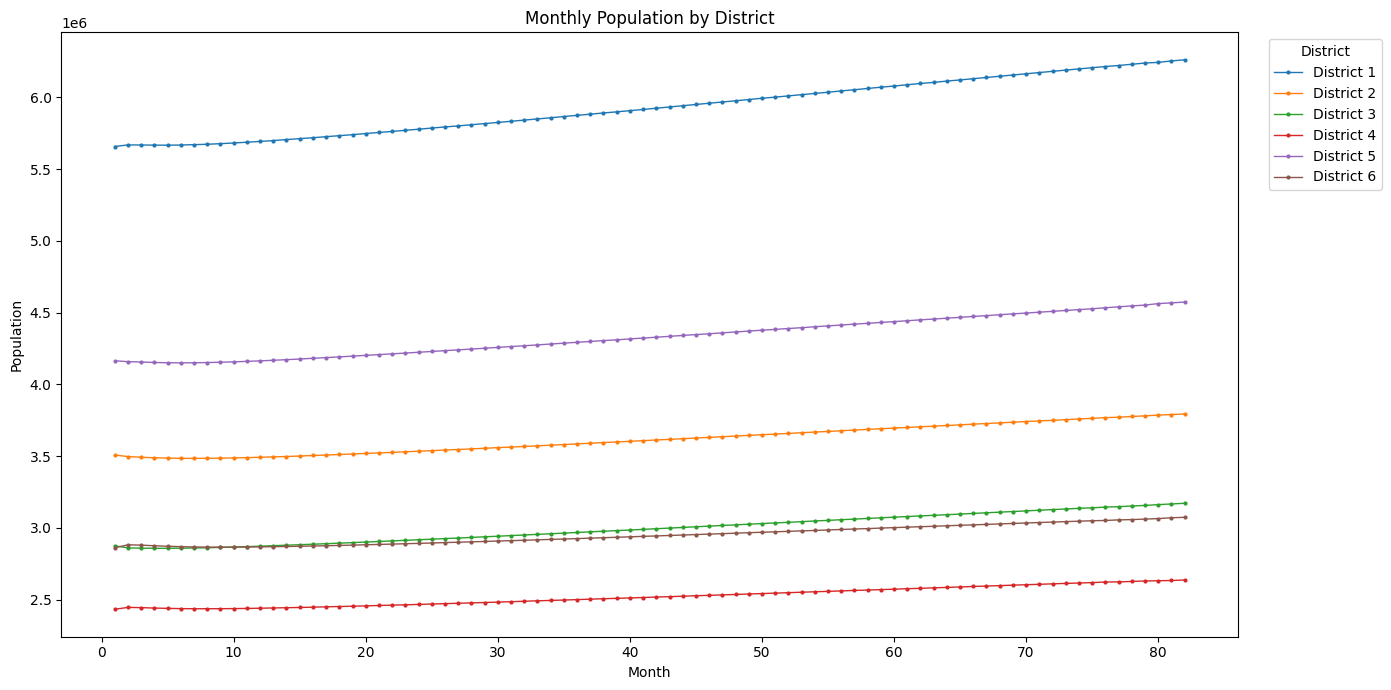

In [7]:
fig, ax = plt.subplots(figsize=(14, 7))

# Plot one line per district (unit_id), using mean_population as the value
for unit_id, group in agg_population.groupby('unit_id'):
    group_sorted = group.sort_values('monthly_data_id')
    ax.plot(
        group_sorted['monthly_data_id'],
        group_sorted['mean_population'],
        label=f'District {unit_id}',
        marker='o',
        markersize=2,
        linewidth=1
    )

ax.set_xlabel('Month')
ax.set_ylabel('Population')
ax.set_title('Monthly Population by District')
ax.legend(title='District', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

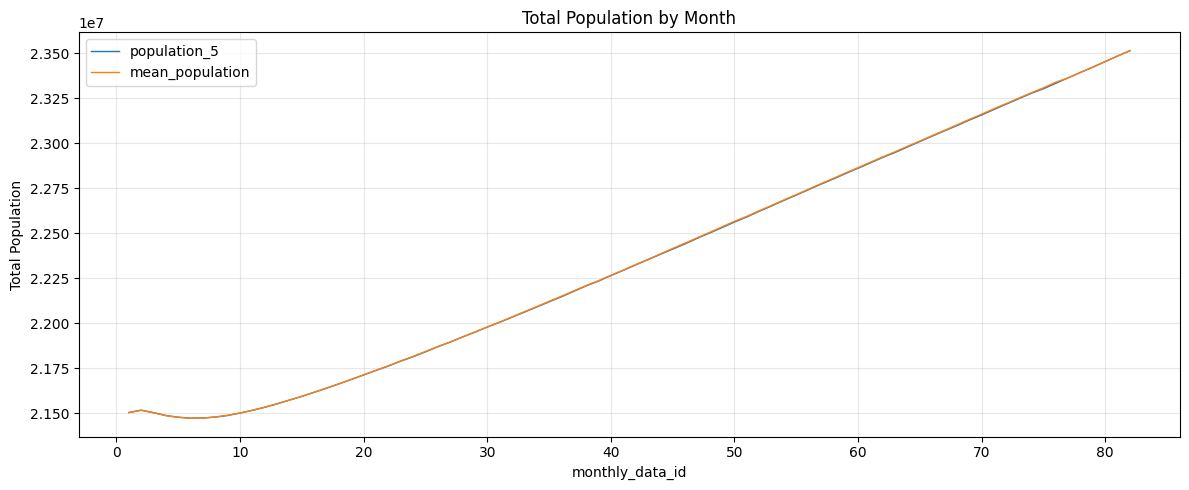

In [8]:
cols = [c for c in total_population.columns if c != 'monthly_data_id']
total_population.plot(
    x='monthly_data_id',
    y=cols,
    figsize=(12, 5),
    legend=True,
    linewidth=1,
    marker=None
)
plt.title("Total Population by Month")
plt.xlabel("monthly_data_id")
plt.ylabel("Total Population")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [9]:
total_population

,monthly_data_id,population_5,mean_population
0,1,21503056.0,21502993
1,2,21516232.0,21516227
2,3,21502128.0,21502555
3,4,21486544.0,21486224
4,5,21477284.0,21476244
...,...,...,...
77,78,23394468.0,23394524
78,79,23424048.0,23423666
79,80,23454800.0,23454800
80,81,23485480.0,23485480
